In [5]:
import fastf1
import os
import logging
logging.getLogger('fastf1').setLevel(logging.ERROR)
import json
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
YEAR = 2026

drivers_json_path = f'./data/{YEAR}/drivers_{YEAR}.json'
if not os.path.exists(drivers_json_path):
    raise FileNotFoundError(f"Drivers JSON file not found at {drivers_json_path}. Please run the driver data extraction first.")

with open(drivers_json_path, 'r') as f:
    drivers_list = json.load(f)
DRIVERS = ['_'.join(driver['id'].split('_')[:-1]) for driver in drivers_list]

schedule = fastf1.get_event_schedule(YEAR)
races = schedule["RoundNumber"][schedule["RoundNumber"] > 0].tolist()

# TODO:
# unprocessed_races = ...

unprocessed_races = [races[0]] # FIXME: temporary

COLUMNS = [
    "driver", "lap_number", "x", "y", "z", "time", "position", "compound", "tyre_life",
    "gap_to_leader", "gap_to_front", "speed", "current_best_lap_time", "last_lap_time",
    "current_sector1_time", "current_sector2_time", "current_sector3_time",
    "best_sector1_time", "best_sector2_time", "best_sector3_time",
    "is_in_pit", "is_retired",
]

DTYPES = {
    "driver": "category",
    "lap_number": "uint16",
    "x": "float32",
    "y": "float32",
    "z": "float32",
    "time": "float32",
    "position": "uint16",
    "compound": "category",
    "tyre_life": "uint16",
    "gap_to_leader": "float32",
    "gap_to_front": "float32",
    "speed": "float32",
    "current_best_lap_time": "float32",
    "last_lap_time": "float32",
    "current_sector1_time": "float32",
    "current_sector2_time": "float32",
    "current_sector3_time": "float32",
    "best_sector1_time": "float32",
    "best_sector2_time": "float32",
    "best_sector3_time": "float32",
    "is_in_pit": "bool",
    "is_retired": "bool",
}

for race in unprocessed_races:
    
    print(f"Processing race {race}...")
    
    session = fastf1.get_session(YEAR, race, "R")
    session.load(laps=True, telemetry=True, weather=False)
    lap_replays = [[] for _ in range(session.total_laps)]
    
    for idx, driver in enumerate(DRIVERS):
        driver_slug = f"{driver}_{YEAR}"
        for _, row in session.results.iterrows():
            if row["DriverId"] == driver:
                driver_abv = row["Abbreviation"]
                break
        driver_laps = session.laps.pick_drivers(driver_abv)
        if driver_laps.empty:
            continue
        
        print(f"\tProcessing driver [{idx+1}/{len(DRIVERS)}] {driver_slug}{'.'*(30-len(driver_slug))}", end="")
        
        best_sectors = [float('inf'), float('inf'), float('inf')]
        best_lap_time = float('inf')
        session_start_time = session.session_start_time.total_seconds()
        
        for driver_lap in driver_laps.iterlaps():            
            lap_telemetry = driver_lap[1].get_telemetry()
            lap_number = int(driver_lap[1]['LapNumber'])
            
            sector1_time = driver_lap[1]['Sector1Time'].total_seconds()
            sector2_time = driver_lap[1]['Sector2Time'].total_seconds()
            sector3_time = driver_lap[1]['Sector3Time'].total_seconds()
            
            lap_time = driver_lap[1]['LapTime'].total_seconds()
            
            for _, row in lap_telemetry.iterrows():  
                
                curr_time_lap = row['Time'].total_seconds()
                
                s1 = min(curr_time_lap, sector1_time) 
                s2 = min(curr_time_lap - s1, sector2_time)
                s3 = min(curr_time_lap - s1 - s2, sector3_time)
                
                position = int(driver_lap[1]['Position']) if not pd.isna(driver_lap[1]['Position']) else len(DRIVERS)
                time = row['SessionTime'].total_seconds() - session_start_time
                    
                speed_ms = row['Speed'] * 1000 / 3600 if not pd.isna(row['Speed']) else 0.0
                interval = row['DistanceToDriverAhead'] / speed_ms if speed_ms > 0 else -1
                
                lap_replays[lap_number - 1].append([
                    driver_slug,                # 0 driver
                    lap_number,                 # 1 lap_number
                    round(row['X'], 2),         # 2 x
                    round(row['Y'], 2),         # 3 y
                    round(row['Z'], 2),         # 4 z
                    round(time, 3),             # 5 time
                    position,                   # 6 position
                    driver_lap[1]['Compound'],  # 7 compound
                    int(driver_lap[1]['TyreLife']),  # 8 tyre_life
                    0,                          # 9 gap_to_leader (calculated later)
                    round(interval, 3),         # 10 gap_to_front
                    round(speed_ms, 3),         # 11 speed
                    round(best_lap_time, 3) if best_lap_time != float('inf') else 0.0,  # 12 current_best_lap_time
                    round(lap_time, 3) if lap_number > 1 else 0.0, # 13 last_lap_time
                    round(s1, 3) if s1 > 0 else 0.0,      # 14 current_sector1_time
                    round(s2, 3) if s2 > 0 else 0.0,      # 15 current_sector2_time
                    round(s3, 3) if s3 > 0 else 0.0,      # 16 current_sector3_time
                    round(best_sectors[0], 3) if best_sectors[0] != float('inf') else 0.0,    # best_sector1_time
                    round(best_sectors[1], 3) if best_sectors[1] != float('inf') else 0.0,    # best_sector2_time
                    round(best_sectors[2], 3) if best_sectors[2] != float('inf') else 0.0,    # best_sector3_time
                    driver_lap[1]["PitInTime"] is not pd.NaT, # is_in_pit
                    False,                      # TODO: # is_retired
                ])
                
            best_sectors = [
                min(best_sectors[0], sector1_time),
                min(best_sectors[1], sector2_time),
                min(best_sectors[2], sector3_time),
            ]
            
            best_lap_time = min(best_lap_time, lap_time)
        
        print("[done]")
            
    print("Sorting and adding gap intervals.....", end="", flush=True)
    
    all_rows = []
    for lap_replay in lap_replays:
        lap_replay.sort(key=lambda x: x[5]) # based on time
        all_rows.extend(lap_replay)
    
    # calculating gap_to_leader based on aggregated gap_to_front
    max_time = max(row[5] for row in all_rows)
    matrix_intervals = [[0] * len(DRIVERS) for _ in range(int(max_time)+1)]
    for row in all_rows:
        interval = row[10]
        time_truncated = int(row[5])
        position = row[6] - 1
        matrix_intervals[time_truncated][position] = interval
    for j in range(len(matrix_intervals)):
        aux = []
        for i in matrix_intervals[j]:
            if not aux:
                aux.append(0)
            else:
                aux.append(round(aux[-1] + i, 3))
        matrix_intervals[j] = aux[:]
    for j in range(len(all_rows)):
        time_truncated = int(all_rows[j][5])
        position = all_rows[j][6] - 1
        all_rows[j][9] = matrix_intervals[time_truncated][position]
    
    df = pd.DataFrame(all_rows, columns=COLUMNS).astype(DTYPES)
    
    # applying a rolling average on gap_to_front because of the high frequency fluctuations
    df = df.sort_values(["driver", "time"]).reset_index(drop=True)
    df["stint"] = df.groupby("driver")["is_in_pit"].transform(lambda x: (x != x.shift()).cumsum())
    def smooth_stint(group):
        t_idx = pd.to_timedelta(group["time"], unit="s")
        s = pd.Series(group["gap_to_front"].values, index=t_idx)
        group["gap_to_front"] = s.rolling("120s", min_periods=1).mean().round(3).values
        return group
    df = df.groupby(["driver", "stint"], group_keys=False).apply(smooth_stint)
    df = df.sort_values("time").drop(columns=["stint"]).reset_index(drop=True)
    all_rows = df[COLUMNS].values.tolist()

    print("[done]", flush=True)
        
    os.makedirs(f'data/{YEAR}/replays', exist_ok=True)
    
    filename = f'data/{YEAR}/replays/replay_{YEAR}_race_{race}.parquet'
    df.to_parquet(filename, engine='fastparquet', compression='zstd', index=False)
    print(f"Wrote {len(df):,} rows to {filename} ({os.path.getsize(filename)/1_048_576:.2f} MiB)")
    
    filename = f'data/{YEAR}/replays/replay_{YEAR}_race_{race}.csv'
    df.to_csv(filename, index=False)
    print(f"Wrote {len(df):,} rows to {filename} ({os.path.getsize(filename)/1_048_576:.2f} MiB)")

Processing race 1...
	Processing driver [1/22] norris_2026...................[done]
	Processing driver [2/22] max_verstappen_2026...........[done]
	Processing driver [3/22] antonelli_2026................[done]
	Processing driver [4/22] leclerc_2026..................[done]
	Processing driver [5/22] hamilton_2026.................[done]
	Processing driver [6/22] hadjar_2026...................[done]
	Processing driver [7/22] russell_2026..................[done]
	Processing driver [8/22] lawson_2026...................[done]
	Processing driver [10/22] arvid_lindblad_2026...........[done]
	Processing driver [11/22] bortoleto_2026................[done]
	Processing driver [12/22] gasly_2026....................[done]
	Processing driver [13/22] stroll_2026...................[done]
	Processing driver [14/22] alonso_2026...................[done]
	Processing driver [15/22] colapinto_2026................[done]
	Processing driver [16/22] ocon_2026.....................[done]
	Processing driver [17/22] 

/tmp/ipykernel_8706/3361383165.py:174: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["stint"] = df.groupby("driver")["is_in_pit"].transform(lambda x: (x != x.shift()).cumsum())
/tmp/ipykernel_8706/3361383165.py:180: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(["driver", "stint"], group_keys=False).apply(smooth_stint)
/tmp/ipykernel_8706/3361383165.py:180: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclud

[done]
Wrote 684,379 rows to data/2026/replays/replay_2026_race_1.parquet (17.51 MiB)
Wrote 684,379 rows to data/2026/replays/replay_2026_race_1.csv (91.01 MiB)


In [ ]:
max_time = max(row[5] for row in all_rows)
all_rows1 = [row[:] for row in all_rows]
matrix_intervals = [[0] * len(DRIVERS) for _ in range(int(max_time)+1)]
for row in all_rows:
    interval = row[10]
    time_truncated = int(row[5])
    position = row[6] - 1
    matrix_intervals[time_truncated][position] = interval
for j in range(len(matrix_intervals)):
    aux = []
    for i in matrix_intervals[j]:
        if not aux:
            aux.append(0)
        else:
            aux.append(round(aux[-1] + i, 3))
    matrix_intervals[j] = aux[:]
for j in range(len(all_rows)):
    time_truncated = int(all_rows[j][5])
    position = all_rows[j][6] - 1
    all_rows1[j][9] = matrix_intervals[time_truncated][position]

[0, 0.12, 0.128, 0.161, 0.181, 0.187, 0.205, 0.209, 0.225, 0.284]
[0, 0.006, 0.035, 0.069, 0.174, 0.234, 0.344, 0.345, 0.373, 0.454]
[0, 0.064, 0.095, 0.157, 0.275, 0.298, 0.338, 0.34, 0.384, 0.397]


In [61]:
count = 0
for row in all_rows[50000:]:
    if row[0] == "norris_2026":
        print(row[0], row[9], row[10])
        count+=1
    if count > 10:
        break
    
print()
count = 0
for row in all_rows[50000:]:
    if row[0] == "perez_2026":
        print(row[0], row[9], row[10])
        count+=1
    if count > 10:
        break

norris_2026 5.4029998779296875 0.797
norris_2026 5.4029998779296875 0.796
norris_2026 5.4029998779296875 0.795
norris_2026 5.4029998779296875 0.794
norris_2026 5.4029998779296875 0.794
norris_2026 5.4029998779296875 0.793
norris_2026 6.748000144958496 0.792
norris_2026 6.748000144958496 0.791
norris_2026 6.748000144958496 0.79
norris_2026 6.748000144958496 0.789
norris_2026 6.748000144958496 0.789

perez_2026 16.722000122070312 1.523
perez_2026 16.722000122070312 1.526
perez_2026 16.722000122070312 1.526
perez_2026 16.722000122070312 1.529
perez_2026 16.722000122070312 1.529
perez_2026 16.722000122070312 1.531
perez_2026 17.892000198364258 1.532
perez_2026 17.892000198364258 1.533
perez_2026 17.892000198364258 1.535
perez_2026 17.892000198364258 1.536
perez_2026 17.892000198364258 1.539


In [ ]:
df = pd.DataFrame(all_rows, columns=COLUMNS).astype(DTYPES)
df = df.sort_values(["driver", "time"]).reset_index(drop=True)
df["stint"] = df.groupby("driver")["is_in_pit"].transform(
    lambda x: (x != x.shift()).cumsum()
)
def smooth_stint(group):
    t_idx = pd.to_timedelta(group["time"], unit="s")
    s = pd.Series(group["gap_to_front"].values, index=t_idx)
    group["gap_to_front"] = s.rolling("120s", min_periods=1).mean().round(3).values
    return group
df = df.groupby(["driver", "stint"], group_keys=False).apply(smooth_stint)
df = df.sort_values("time").drop(columns=["stint"]).reset_index(drop=True)
all_rows1 = df[COLUMNS].values.tolist()

/tmp/ipykernel_8706/1321588263.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["stint"] = df.groupby("driver")["is_in_pit"].transform(
/tmp/ipykernel_8706/1321588263.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = df.groupby(["driver", "stint"], group_keys=False).apply(smooth_stint)
/tmp/ipykernel_8706/1321588263.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the

,driver,lap_number,x,y,z,time,position,compound,tyre_life,gap_to_leader,...,current_best_lap_time,last_lap_time,current_sector1_time,current_sector2_time,current_sector3_time,best_sector1_time,best_sector2_time,best_sector3_time,is_in_pit,is_retired
0,hadjar_2026,1,-939.000000,-1578.000000,86.000000,0.000000,4,MEDIUM,1,-1.000000,...,0.000000,0.000000,0.000,0.000,0.000000,0.000,0.000000,0.000000,False,False
1,arvid_lindblad_2026,1,-609.000000,-1892.000000,89.000000,0.000000,5,MEDIUM,1,-1.000000,...,0.000000,0.000000,0.000,0.000,0.000000,0.000,0.000000,0.000000,False,False
2,stroll_2026,1,140.000000,-2618.000000,89.000000,0.000000,20,MEDIUM,1,-1.000000,...,0.000000,0.000000,0.000,0.000,0.000000,0.000,0.000000,0.000000,False,False
3,russell_2026,1,-1050.000000,-1472.000000,86.000000,0.000000,2,MEDIUM,1,-1.000000,...,0.000000,0.000000,0.000,0.000,0.000000,0.000,0.000000,0.000000,False,False
4,lawson_2026,1,-681.000000,-1823.000000,88.000000,0.000000,18,MEDIUM,1,-1.000000,...,0.000000,0.000000,0.000,0.000,0.000000,0.000,0.000000,0.000000,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
684374,stroll_2026,43,-913.960022,-1600.939941,86.620003,5067.621094,17,SOFT,4,80.584000,...,85.410004,85.918999,29.948,18.837,36.583000,29.694,18.466999,36.943001,False,False
684375,stroll_2026,43,-1074.000000,-1449.000000,85.000000,5067.813965,17,SOFT,4,80.777000,...,85.410004,85.918999,29.948,18.837,36.776001,29.694,18.466999,36.943001,False,False
684376,stroll_2026,43,-1116.959961,-1408.199951,84.790001,5067.900879,17,SOFT,4,80.863998,...,85.410004,85.918999,29.948,18.837,36.862999,29.694,18.466999,36.943001,False,False
684377,stroll_2026,43,-1177.000000,-1351.000000,85.000000,5068.113770,17,SOFT,4,81.077003,...,85.410004,85.918999,29.948,18.837,37.076000,29.694,18.466999,36.943001,False,False


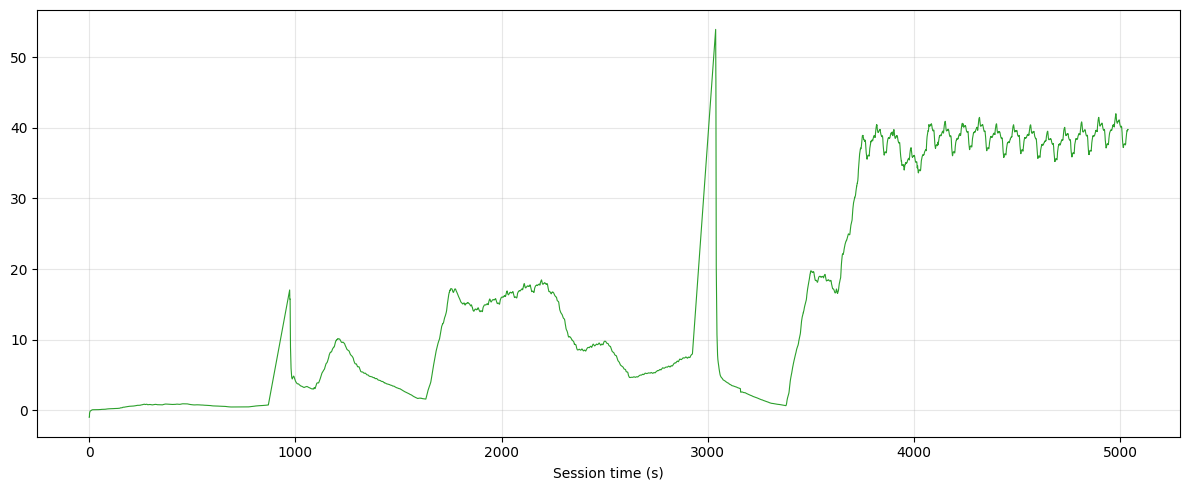

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

DRIVER = "norris_2026"

all_rows_aux = all_rows1[:]
_df = pd.DataFrame(all_rows_aux, columns=COLUMNS)
driver_slug = DRIVER if DRIVER is not None else _df["driver"].iloc[0]

# _sub = _df[(_df["driver"] == driver_slug) & (_df["gap_to_front"] >= 0)].sort_values("time")
# q1 = _sub["gap_to_front"].quantile(0.25)
# q3 = _sub["gap_to_front"].quantile(0.75)
# iqr = q3 - q1
# lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
# _sub = _sub[(_sub["gap_to_front"] >= lo) & (_sub["gap_to_front"] <= hi)]
# y_axis = _sub["gap_to_front"]
# x_axis = _sub["time"] 

def min_max_scale(series):
    s_min, s_max = series.min(), series.max()
    return (series - s_min) / (s_max - s_min) if s_max > s_min else series

_sub = _df[(_df["driver"] == driver_slug) & (_df["is_in_pit"] == False)].sort_values("time")
_sub["gap_to_front_smooth"] = _sub.set_index(pd.to_timedelta(_sub["time"], unit="s"))["gap_to_front"].rolling("120s").mean().values

scaled_ys = [
    min_max_scale(_sub["speed"]),
    # min_max_scale(_sub["gap_to_front"].ewm(span=200).mean()),
    # min_max_scale(_sub["gap_to_front_smooth"]),
    _sub["gap_to_front"],
    # _sub["gap_to_leader"]
]

fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(_sub["time"], scaled_ys[0], linewidth=0.8, color="tab:red")
ax.plot(_sub["time"], scaled_ys[1], linewidth=0.8, color="tab:green")
# ax.plot(_sub["time"], scaled_ys[2], linewidth=0.8, color="tab:blue")
ax.set_xlabel("Session time (s)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


In [ ]:
import fastf1
import logging
logging.getLogger('fastf1').setLevel(logging.ERROR)
import pandas as pd
import os
import json
YEAR=2026
session = fastf1.get_session(YEAR, 1, "R")
drivers_json_path = f'./data/{YEAR}/drivers_{YEAR}.json'
if not os.path.exists(drivers_json_path):
    raise FileNotFoundError(f"Drivers JSON file not found at {drivers_json_path}. Please run the driver data extraction first.")

with open(drivers_json_path, 'r') as f:
    drivers_list = json.load(f)
DRIVERS = ['_'.join(driver['id'].split('_')[:-1]) for driver in drivers_list]
session.load(laps=True, telemetry=True, weather=False)

abv = "VER"
driver_laps = session.laps.pick_drivers(abv)
session_start_time = session.session_start_time.total_seconds()
for driver_lap in driver_laps.iterlaps():            
    lap_telemetry = driver_lap[1].get_telemetry()
    for _, row in lap_telemetry.iterrows():
        time = row['SessionTime'].total_seconds() - session_start_time
        lap_number = driver_lap[1]['LapNumber']
        driver_ahead = row['DriverAhead']
        speed_ms = row['Speed'] * 1000 / 3600
        interval = row['DistanceToDriverAhead'] / speed_ms if speed_ms > 0 else -1
        if driver_lap[1]['Position'] == 1:
            time_leader = time
        gap_leader = time - time_leader if time_leader > 0 else -1
        print(f"[{time:.2f} s] {abv} - Lap {lap_number} - Pos {driver_lap[1]['Position']} - DriverAhead: {driver_ahead} - Interval: {interval:.3f} - Gap to leader: {gap_leader:.3f}")
    

[0.00 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead:  - Interval: -1.000 - Gap to leader: -1.000
[0.05 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead:  - Interval: -1.000 - Gap to leader: -1.000
[0.21 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead:  - Interval: -1.000 - Gap to leader: -1.000
[0.33 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead:  - Interval: -1.000 - Gap to leader: -1.000
[0.41 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead:  - Interval: -1.000 - Gap to leader: -1.000
[0.53 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead:  - Interval: -1.000 - Gap to leader: -1.000
[0.75 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead:  - Interval: -1.000 - Gap to leader: -1.000
[0.89 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead: 23 - Interval: -1.000 - Gap to leader: -1.000
[0.97 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead: 23 - Interval: 0.510 - Gap to leader: 0.510
[1.16 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead: 87 - Interval: 0.156 - Gap to leader: 0.156
[1.31 s] VER - Lap 1.0 - Pos 16.0 - DriverAhead: 87 - Interval: 0.10

In [ ]:
from scipy.spatial import KDTree

def create_minisectors_position_references(race_id, year):
    
    session = fastf1.get_session(year, race_id, 'Q')
    session.load()
    fastest_lap = session.laps.pick_fastest()
    pos_data = fastest_lap.get_pos_data().copy()

    s1_end = fastest_lap['Sector1SessionTime']
    s2_end = fastest_lap['Sector2SessionTime']

    conditions = [
        pos_data['SessionTime'] <= s1_end,
        (pos_data['SessionTime'] > s1_end) & (pos_data['SessionTime'] <= s2_end),
        pos_data['SessionTime'] > s2_end
    ]
    choices = [1, 2, 3]

    pos_data['Sector'] = np.select(conditions, choices, default=3)

    track_x = pos_data['X']
    track_y = pos_data['Y']
    track_s = pos_data['Sector']

    perimeter = 0.0
    for i in range(len(track_x) - 1):
        dx = track_x[i + 1] - track_x[i]
        dy = track_y[i + 1] - track_y[i]
        perimeter += (dx**2 + dy**2)**0.5

    dx = np.diff(track_x)
    dy = np.diff(track_y)
    segment_lengths = np.hypot(dx, dy)
    cum_distance = np.insert(np.cumsum(segment_lengths), 0, 0.0)
    total_length = cum_distance[-1]
    # minisectors amount (between 6 and 8 per sector, so 24 is a good number)
    MS_AMOUNT = 24 
    track_ms = np.minimum((cum_distance / total_length * MS_AMOUNT).astype(int), MS_AMOUNT - 1)
    track_coords = np.column_stack((track_x, track_y))
    
    kdtree = KDTree(track_coords)

    def func(driver_x, driver_y):
        query_pts = np.atleast_2d(np.column_stack((driver_x, driver_y)) if np.ndim(driver_x) > 0 else [driver_x, driver_y])
        _, indices = kdtree.query(query_pts)
        
        result = track_ms[indices]
        return result[0] if np.ndim(driver_x) == 0 else result
    
    return {
        "track_points": list(zip(track_x, track_y, track_s, track_ms)), 
        "get_minisector_by_position": func
    }


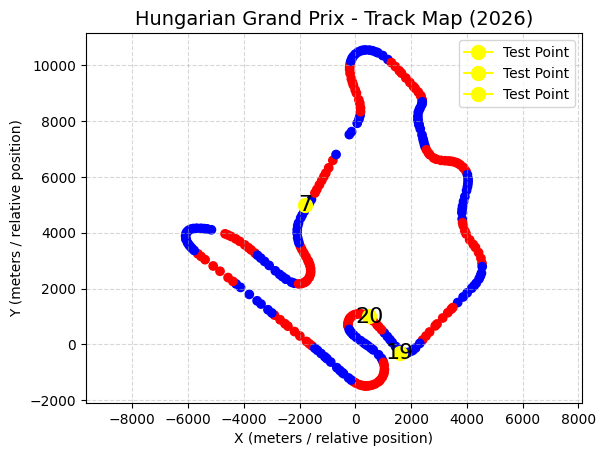

In [29]:
minisectors = create_minisectors_position_references(11, 2026)

# teste:
X, Y = 1600, -300
plt.plot(X, Y, marker='o', markersize=10, color='yellow', label='Test Point')

idx = minisectors["get_minisector_by_position"](X, Y, minisectors["track_points"])
plt.text(X, Y, str(idx), fontsize=16, color='black', ha='center', va='center')

X, Y = -1800, 5000
plt.plot(X, Y, marker='o', markersize=10, color='yellow', label='Test Point')
minisectors = create_minisectors_position_references(11, 2026)
idx = minisectors["get_minisector_by_position"](X, Y, minisectors["track_points"])
plt.text(X, Y, str(idx), fontsize=16, color='black', ha='center', va='center')

X, Y = 500, 1000
plt.plot(X, Y, marker='o', markersize=10, color='yellow', label='Test Point')
minisectors = create_minisectors_position_references(11, 2026)
idx = minisectors["get_minisector_by_position"](X, Y, minisectors["track_points"])
plt.text(X, Y, str(idx), fontsize=16, color='black', ha='center', va='center')

ms_x = [point[0] for point in minisectors["track_points"]]
ms_y = [point[1] for point in minisectors["track_points"]]
colors = ['red' if point[3] % 2 == 0 else 'blue' for point in minisectors["track_points"]]
plt.scatter(ms_x, ms_y, color=colors)
plt.title(f"{session.event['EventName']} - Track Map ({session.event.year})", fontsize=14)
plt.xlabel("X (meters / relative position)")
plt.ylabel("Y (meters / relative position)")
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [33]:
session = fastf1.get_session(2026, 11, 'R')
session.load()
driver_laps = session.laps.pick_driver('BOT')
for lap in driver_laps.iterlaps():
    lap_telemetry = lap[1].get_telemetry()
    for _, row in lap_telemetry.iterrows():
        print(f"Lap {lap[1]['LapNumber']} - Time: {row['SessionTime']} - Retired: {lap[1]['FastF1Generated']}")

/home/matheus/Documents/separados/prettyf1/scripts/venv/lib/python3.10/site-packages/fastf1/core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Lap 1.0 - Time: 0 days 00:54:08.019000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:08.194000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:08.257000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:08.434000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:08.457000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:08.637000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:08.714000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:09.034000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:09.057000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:09.274000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:09.478000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:09.515000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:09.675000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:09.698000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:09.955000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:09.958000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:10.258000 - Retired: False
Lap 1.0 - Time: 0 days 00:54:10.315000 - Retired

In [21]:
import fastf1
import numpy as np
import pandas as pd
import logging
logging.getLogger('fastf1').setLevel(logging.ERROR)

session = fastf1.get_session(2026, 11, "R")
session.load(laps=True, telemetry=True, weather=False)
driver_laps = session.laps.pick_drivers("VER")
laps_telemetry = driver_laps.get_telemetry()

In [ ]:
laps_meta = driver_laps[[
    'LapNumber', 'Position', 'Compound', 'TyreLife', 'PitInTime', 'PitOutTime',
    'Sector1Time', 'Sector2Time', 'Sector3Time', 'LapTime', 'LapStartTime'
]].copy()

for col in ['Sector1Time', 'Sector2Time', 'Sector3Time', 'LapTime']:
    laps_meta[col + '_sec'] = laps_meta[col].dt.total_seconds().fillna(0.0).astype(np.float32)
laps_telemetry = laps_telemetry.sort_values('SessionTime')
merged = pd.merge_asof(
    laps_telemetry,
    laps_meta,
    left_on='SessionTime',
    right_on='LapStartTime',
    direction='backward'
)
time_sec_float = (merged['Time'].dt.total_seconds()).to_numpy()
merged['time_sec_int'] = np.floor(time_sec_float).astype(np.int32)

merged = merged.drop_duplicates(subset=['time_sec_int'], keep='last').copy()

time_arr = (merged['SessionTime'].dt.total_seconds() - session_start_time).to_numpy(dtype=np.float32)
curr_lap_time = merged.groupby('LapNumber')['Time'].transform(lambda s: s - s.iloc[0])
curr_lap_time = curr_lap_time.dt.total_seconds().to_numpy(dtype=np.float32)

s1_target = merged['Sector1Time_sec'].to_numpy()
s2_target = merged['Sector2Time_sec'].to_numpy()
s3_target = merged['Sector3Time_sec'].to_numpy()

# extracting the current sector timestamp (multiple lap telemetry data points) 
# and clipping to not exceed the final sector times (single lap data point)
merged['s1'] = np.clip(curr_lap_time, 0, s1_target)
merged['s2'] = np.clip(curr_lap_time - merged['s1'], 0, s2_target)
merged['s3'] = np.clip(curr_lap_time - merged['s1'] - merged['s2'], 0, s3_target)


Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: 0 days 01:14:14.527000, Pit Out: NaT
Pit In: NaT, Pit Out: 0 days 01:14:36.174000
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
Pit In: NaT, Pit Out: NaT
